In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

In [ ]:
# TODO:

# 870.30

In [3]:
df = pd.read_csv('data-treatment.csv', )

In [4]:
df.head(5)

,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,mes,ano_mes,horas,dia,regiao
0,13/08/2007,Segunda,14:25:00,MG,40,585.5,ITABIRITO,Outras,Saída de Pista,Com Vítimas Feridas,...,1,2,0,1,1,8,2007-08-01,14,13,Sudeste
1,12/02/2007,Segunda,02:10:00,MA,135,11.0,SAO LUIS,Animais na Pista,Atropelamento de animal,Com Vítimas Fatais,...,1,0,0,3,1,2,2007-02-01,2,12,Nordeste
2,20/11/2007,Terça,05:30:00,CE,222,30.8,CAUCAIA,Defeito mecânico em veículo,Capotamento,Com Vítimas Feridas,...,0,0,0,1,1,11,2007-11-01,5,20,Nordeste
3,16/12/2007,Domingo,17:40:00,MA,230,14.0,BARAO DE GRAJAU,Outras,Capotamento,Com Vítimas Feridas,...,1,0,0,1,1,12,2007-12-01,17,16,Nordeste
4,05/03/2007,Segunda,08:10:00,PR,277,584.4,CASCAVEL,Outras,Colisão lateral,Sem Vítimas,...,0,2,0,0,2,3,2007-03-01,8,5,Sul


In [5]:
df.describe().round(2)

,br,km,ano,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,mes,horas,dia
count,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00,1465676.00
mean,212.00,262.29,2011.08,2.15,0.05,0.43,0.16,1.43,0.08,0.59,1.75,6.57,13.05,15.64
std,128.82,230.12,2.41,1.54,0.28,0.97,0.56,1.21,0.38,1.19,0.72,3.49,5.82,8.76
min,0.00,-870.30,2007.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00
25%,101.00,79.00,2009.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,4.00,8.00,8.00
50%,153.00,202.80,2011.00,2.00,0.00,0.00,0.00,1.00,0.00,0.00,2.00,7.00,14.00,16.00
75%,324.00,411.50,2013.00,2.00,0.00,1.00,0.00,2.00,0.00,1.00,2.00,10.00,18.00,23.00
max,958.00,9967.10,2015.00,248.00,33.00,52.00,222.00,99.00,86.00,239.00,25.00,12.00,23.00,31.00


In [6]:
# Deixar a função com argumentos adicionais para personalizar mais

def plot_bar(lista, freq_values):
    # TODO: Adicionar docstring + valores opcionais
    fig, ax = plt.subplots(figsize=(9,3))

    ax.bar(lista, freq_values, edgecolor='black', linewidth=0.7)

    ax.set(xlim=(0, 8), xticks=np.arange(-1, len(lista)+1))

    plt.show()

- Quais são os 10 estados com maior número de acidentes registrados?

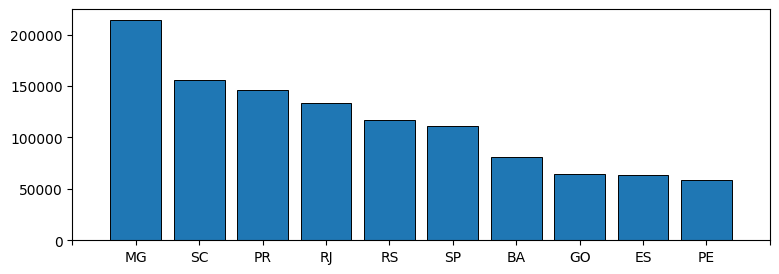

In [7]:
analysis = df.groupby(['uf'])['uf'].count().sort_values(ascending=False)
plot_bar(analysis.iloc[:10].index,analysis.iloc[:10].values)


In [8]:
df.columns

Index(['data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio',
       'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia',
       'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via',
       'uso_solo', 'ano', 'pessoas', 'mortos', 'feridos_leves',
       'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'mes',
       'ano_mes', 'horas', 'dia', 'regiao'],
      dtype='str')

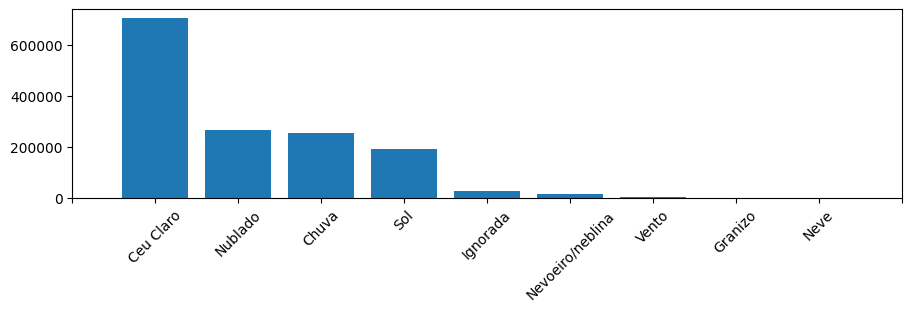

In [9]:
a = df.groupby(['condicao_metereologica'])['condicao_metereologica'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9,3), layout="constrained")

ax.bar(a.index, a.values, linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(-1, len(a.index)+1))

ax.tick_params("x", rotation=45)

plt.show()

In [10]:
a = df.groupby(['condicao_metereologica'])['condicao_metereologica'].count().sort_values(ascending=False)


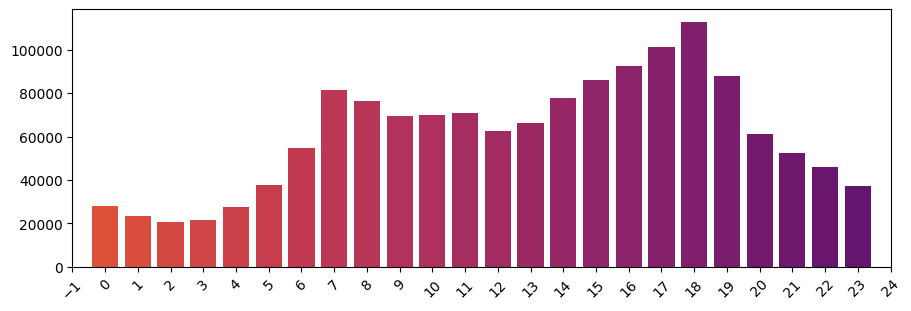

In [11]:
a= df.groupby(['horas'])['horas'].count()

color = cm.inferno_r(np.linspace(.4, .8, 30))

fig, ax = plt.subplots(figsize=(9,3), layout="constrained")

ax.bar(a.index, a.values, linewidth=0.7, color = color)

ax.set(xlim=(0, 8), xticks=np.arange(-1, len(a.index)+1))

ax.tick_params("x", rotation=45)

plt.show()

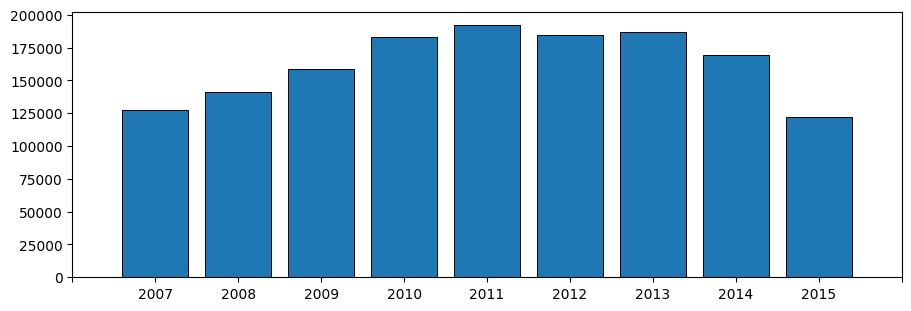

In [12]:
a = df.groupby(['ano'])['ano'].count()

fig, ax = plt.subplots(figsize=(9,3), layout="constrained")

ax.bar(a.index.astype(str), a.values, edgecolor='black', linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(-1, len(a.index)+1))

plt.show()

In [13]:
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

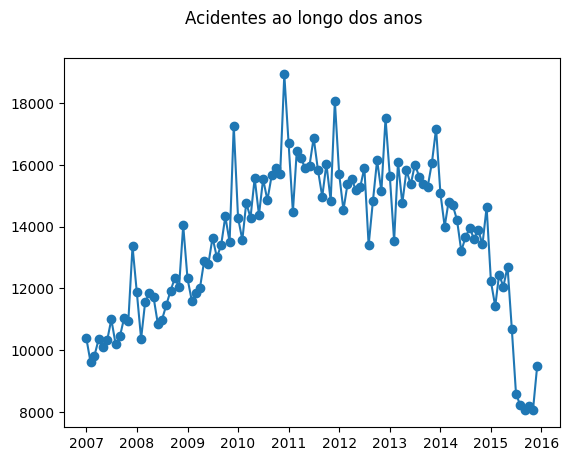

In [14]:
a = df.groupby(['ano_mes'])['ano_mes'].count()

fig = plt.figure()

fig.suptitle('Acidentes ao longo dos anos')

ax = fig.add_subplot()

ax.plot(a.index, a.values, '-o')

#ax.set(xticks=np.arange(1, len(lista_series)+1))

plt.show()

- Qual é a distribuição de acidentes por dia da semana?

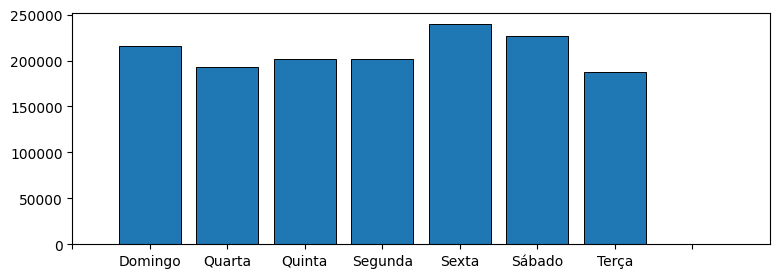

In [15]:
a = df.groupby(['dia_semana'])['dia_semana'].count()
plot_bar(a.index, a.values)

- Quais meses do ano concentram mais acidentes e mortes?

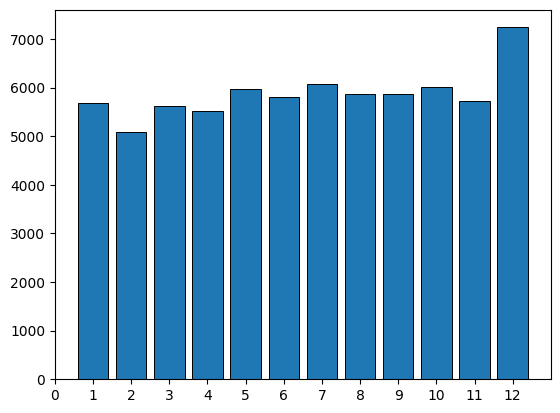

In [16]:
a = df.groupby(['mes'])['mortos'].sum()

fig, ax = plt.subplots()

ax.bar(a.index, a.values, edgecolor='blacK', linewidth=0.7)

ax.set(xlim = (0, len(a.index)+1), xticks=np.arange(0, len(a.index)+1))

plt.show()


- Existe interação entre dia da semana e horário que eleva a gravidade dos acidentes?

In [17]:
a = df.groupby(['dia_semana', 'horas', 'classificacao_acidente'])[['classificacao_acidente']].count()
a

classificacao_acidente
dia_semana horas classificacao_acidente                        
Domingo    0     Com Vítimas Fatais                         446
                 Com Vítimas Feridas                       2499
                 Ignorado                                   107
                 Sem Vítimas                               2471
           1     Com Vítimas Fatais                         380
...                                                         ...
Terça      22    Sem Vítimas                               2904
           23    Com Vítimas Fatais                         242
                 Com Vítimas Feridas                       1548
                 Ignorado                                    49
                 Sem Vítimas                               2353

[672 rows x 1 columns]

- A redução de acidentes ao longo dos anos é uniforme entre estados ou concentrada em alguns?

In [18]:
# Aqui eu posso reaproveitar aquele lá, mas acho que ficaria mt poluído, vou procurar outro por enquanto

df.groupby(['uf', 'ano'])['ano'].count()

uf  ano 
AC  2007     324
    2008     353
    2009     365
    2010     462
    2011     518
            ... 
TO  2011    1090
    2012    1179
    2013    1279
    2014    1301
    2015     872
Name: ano, Length: 243, dtype: int64

- Quais rodovias federais concentram o maior número de mortes?

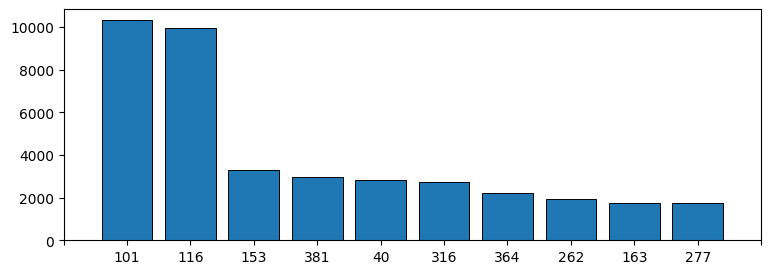

In [19]:
# porra, e eu fazendo tudo na mão, eu esqueci completamente do pandas
# MEUDEUS É MT MAIS FÁCIL CARA, tipo, aqui já tá tudo ordenado, nem me preocupar eu tenho

plot_bar((df.groupby(['br']) # juntamos por estradas
          ['mortos'].sum()) # aplicamos uma soma da coluna que diz respeito aos falecidos no acidente
          .sort_values(ascending=False) # ordenamos para pegar os maiores
          .iloc[:10].index.astype(str) # aqui estou passando apenas o índice, já que fiz a função para ser assim mesmo
          # aqui é p passar os valores realmente
          , (df.groupby(['br'])['mortos'].sum()).sort_values(ascending=False).iloc[:10].values)

- Quais municípios têm a maior taxa de mortalidade por acidente?

In [20]:
# TODO: estudar como fazer isso aqui, pq eu preciso filtrar acidentes considerados fatais e pegar todos os outros para inferirmos uma taxa

#df.groupby(['municipio']).apply(f)


"""
(df.groupby(['municipio', 'classificacao_acidente'])['classificacao_acidente'].agg({
    'a': 'count',
    'b'
}
).sort_values(ascending=False)
"""

"\n(df.groupby(['municipio', 'classificacao_acidente'])['classificacao_acidente'].agg({\n    'a': 'count',\n    'b'\n}\n).sort_values(ascending=False)\n"

- Existe concentração de acidentes em trechos específicos de rodovias (pontos negros)?

In [21]:
# para vermos a questão da concentração de acidentes em trechos específicos, vamos precisar pegar o total e dividir em certos pontos da pista

# primeiro, como pegamos a quantidade total de acidentes nas próprias rodovias
df.groupby(['br', 'km'])['km'].count()

br   km   
0    9.5      1
     68.0     1
     69.3     1
     128.9    1
     165.0    1
             ..
869  490.4    1
870  1.0      1
884  46.0     1
931  123.0    1
958  447.9    1
Name: km, Length: 180269, dtype: int64

- Como a proporção entre acidentes urbanos e rurais varia por região do Brasil?

In [22]:
# TODO: Estudar representação disso
df.groupby(['regiao', 'uso_solo'])['regiao'].count()

regiao        uso_solo
Centro-Oeste  Rural        84958
              Urbano       53039
Nordeste      Rural       141183
              Urbano      166778
Norte         Rural        29109
              Urbano       48738
Sudeste       Rural       268690
              Urbano      253764
Sul           Rural       172179
              Urbano      247238
Name: regiao, dtype: int64

- Quais são as 10 causas mais frequentes de acidentes no Brasil?

In [23]:
# TODO: Estudar representação disso
df.groupby(['causa_acidente'])['causa_acidente'].count().sort_values(ascending=False)

causa_acidente
Falta de atenção                      480936
Outras                                426509
Não guardar distância de segurança    133613
Velocidade incompatível               121579
Desobediência à sinalização            58829
Defeito mecânico em veículo            57806
Ingestão de álcool                     55092
Animais na Pista                       39214
Dormindo                               37146
Ultrapassagem indevida                 32928
Defeito na via                         22024
Name: causa_acidente, dtype: int64

- Quais causas estão associadas à maior letalidade?

In [24]:
#df.groupby(['causa_acidente', 'mortos']).sum()

- A participação relativa de cada causa mudou ao longo dos anos?

In [25]:
# TODO: Estudar forma de representar isso
df.groupby(['causa_acidente', 'ano'])[['causa_acidente']].count()

causa_acidente
causa_acidente          ano                 
Animais na Pista        2007            4201
                        2008            4582
                        2009            4205
                        2010            4802
                        2011            5008
...                                      ...
Velocidade incompatível 2011           16169
                        2012           16829
                        2013           18694
                        2014           17715
                        2015           14259

[99 rows x 1 columns]

- Existe associação entre causa do acidente e tipo de pista ou traçado da via?

In [26]:
df.columns

Index(['data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio',
       'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia',
       'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via',
       'uso_solo', 'ano', 'pessoas', 'mortos', 'feridos_leves',
       'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'mes',
       'ano_mes', 'horas', 'dia', 'regiao'],
      dtype='str')

In [27]:
# TODO: Estudar forma de representar isso, e se isso está bom
df.groupby(['causa_acidente', 'tipo_pista', 'tracado_via'])[['causa_acidente']].count()

causa_acidente
causa_acidente          tipo_pista tracado_via                
Animais na Pista        Dupla      Cruzamento               50
                                   Curva                   961
                                   Reta                   7338
                        Múltipla   Cruzamento               12
                                   Curva                    32
...                                                        ...
Velocidade incompatível Múltipla   Curva                  1758
                                   Reta                   2518
                        Simples    Cruzamento             2129
                                   Curva                 43204
                                   Reta                  19859

[99 rows x 1 columns]

- Qual a proporção entre acidentes sem vítimas, com feridos e com mortos?

In [28]:
# proporção seria 

- A relação entre feridos leves e graves varia conforme o tipo de acidente?

In [29]:
df.groupby(['tipo_acidente', 'feridos_graves', 'feridos_leves'])[['tipo_acidente']].count()

tipo_acidente
tipo_acidente           feridos_graves feridos_leves               
Atropelamento de animal 0              0                      25079
                                       1                       4398
                                       2                       1237
                                       3                        187
                                       4                         97
...                                                             ...
Tombamento              16             10                         1
                        18             17                         1
                        20             21                         1
                        21             2                          1
                        39             0                          1

[1530 rows x 1 columns]

- Quais variáveis têm maior correlação com o número de mortos por acidente?

- Acidentes com mais veículos envolvidos resultam proporcionalmente em mais mortes?

In [30]:
df.groupby(['veiculos'])[['mortos']].sum()

,mortos
veiculos,
1,26179
2,36081
3,6156
4,1291
5,412
6,160
7,70
8,40
9,25


- Acidentes em chuva são mais graves do que em tempo claro?

In [31]:
# Vai ter que ter a frequência relativa, só isso não é suficiente para comparar
t = (df.groupby(['condicao_metereologica', 'classificacao_acidente'])[['classificacao_acidente']].count())
print(t.loc['Ceu Claro'].sum())
print(t.loc['Chuva'].sum())

classificacao_acidente    704850
dtype: int64
classificacao_acidente    255512
dtype: int64


- A condição meteorológica influencia o tipo de acidente mais frequente?


In [32]:
df['tipo_acidente'].unique()

<ArrowStringArray>
[                            'Saída de Pista',
                    'Atropelamento de animal',
                                'Capotamento',
                            'Colisão lateral',
                    'Atropelamento de pessoa',
                           'Colisão traseira',
                        'Colisão Transversal',
                                 'Tombamento',
                    'Colisão com objeto fixo',
                            'Danos Eventuais',
 'Queda de motocicleta / bicicleta / veículo',
                      'Derramamento de Carga',
                      'Colisão com bicicleta',
                   'Colisão com objeto móvel',
                            'Colisão frontal',
                                   'Incêndio']
Length: 16, dtype: str

In [33]:
df.groupby(['condicao_metereologica', 'tipo_acidente'])[['tipo_acidente']].count()

tipo_acidente
condicao_metereologica tipo_acidente                                            
Ceu Claro              Atropelamento de animal                             21050
                       Atropelamento de pessoa                             23105
                       Capotamento                                         28914
                       Colisão Transversal                                 76240
                       Colisão com bicicleta                               10202
...                                                                          ...
Vento                  Derramamento de Carga                                  24
                       Incêndio                                               28
                       Queda de motocicleta / bicicleta / veículo            155
                       Saída de Pista                                        500
                       Tombamento                                            222

[139 rows x 1 columns]

- Qual tipo de pista concentra mais acidentes fatais?


In [34]:
df.groupby(['tipo_pista', 'classificacao_acidente'])[['classificacao_acidente']].count()

classificacao_acidente
tipo_pista classificacao_acidente                        
Dupla      Com Vítimas Fatais                       14445
           Com Vítimas Feridas                     190648
           Ignorado                                  4245
           Sem Vítimas                             377305
Múltipla   Com Vítimas Fatais                        2023
           Com Vítimas Feridas                      31985
           Ignorado                                   634
           Sem Vítimas                              77464
Simples    Com Vítimas Fatais                       41024
           Com Vítimas Feridas                     302821
           Ignorado                                  5125
           Sem Vítimas                             417957

- O traçado da via influencia a gravidade dos acidentes?


In [35]:
df.groupby(['tracado_via', 'classificacao_acidente'])[['classificacao_acidente']].count()

classificacao_acidente
tracado_via classificacao_acidente                        
Cruzamento  Com Vítimas Fatais                        1389
            Com Vítimas Feridas                      35208
            Ignorado                                   343
            Sem Vítimas                              59868
Curva       Com Vítimas Fatais                       13741
            Com Vítimas Feridas                     116959
            Ignorado                                  2745
            Sem Vítimas                             181936
Reta        Com Vítimas Fatais                       42362
            Com Vítimas Feridas                     373287
            Ignorado                                  6916
            Sem Vítimas                             630922

- Existe um perfil de risco combinando tipo de pista, traçado e condição meteorológica?


In [36]:
df.groupby(['tracado_via', 'classificacao_acidente', 'condicao_metereologica'])[['classificacao_acidente']].count()

classificacao_acidente
tracado_via classificacao_acidente condicao_metereologica                        
Cruzamento  Com Vítimas Fatais     Ceu Claro                                  789
                                   Chuva                                      103
                                   Ignorada                                    24
                                   Nevoeiro/neblina                            30
                                   Nublado                                    264
...                                                                           ...
Reta        Sem Vítimas            Neve                                        38
                                   Nevoeiro/neblina                          5521
                                   Nublado                                 113532
                                   Sol                                      92581
                                   Vento                                     1662

[100 rows x 1 columns]

- O perfil de causas de acidentes mudou entre o início e o fim do período analisado?


In [37]:
df.groupby(['tipo_acidente', 'ano'])[['tipo_acidente']].count()

tipo_acidente
tipo_acidente           ano                
Atropelamento de animal 2007           3556
                        2008           3868
                        2009           3712
                        2010           4250
                        2011           4446
...                                     ...
Tombamento              2011           6969
                        2012           7242
                        2013           6981
                        2014           6808
                        2015           5630

[144 rows x 1 columns]

- A letalidade dos acidentes melhorou ao longo do tempo em cada UF?


In [38]:
df.groupby(['uf', 'ano'])[['mortos']].sum()

mortos
uf ano         
AC 2007      20
   2008      13
   2009      31
   2010      14
   2011      23
...         ...
TO 2011     129
   2012     114
   2013     110
   2014     117
   2015      93

[243 rows x 1 columns]

- Existem picos atípicos de acidentes em datas específicas como feriados e carnaval?


In [39]:
# temos, mas como podemos mostrar isso ? além da questão da série temporal

- É possível segmentar os acidentes em grupos com perfis distintos de risco?

In [40]:
# usar algum método de clusterização 


- Quais UFs apresentam comportamento atípico em relação à média nacional de fatalidade?

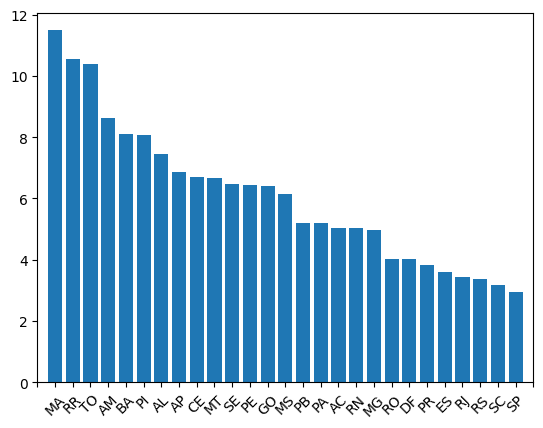

In [41]:
a = (df.groupby(['uf'])['mortos'].mean()*100).round(2).sort_values(ascending=False)

fig, ax = plt.subplots()

ax.bar(a.index, a.values, linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(-1, len(a.index)+1))

ax.tick_params("x", rotation=45)

plt.show()
